# Step 1: Import Libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# Step 2: Load Dataset

In [8]:
df = pd.read_csv("C:/Users/MONIKA/Downloads/sales_data.csv")
print(df.head())
print(df.info())

   Order Date Region     Product  Sales  Profit
0  2024-01-05  North      Laptop  50000   10000
1  2024-01-10  South      Mobile  30000    6000
2  2024-01-15   East      Tablet  20000    4000
3  2024-01-20   West  Headphones  10000    2000
4  2024-02-03  North      Mobile  35000    7000
<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Order Date  48 non-null     str  
 1   Region      48 non-null     str  
 2   Product     48 non-null     str  
 3   Sales       48 non-null     int64
 4   Profit      48 non-null     int64
dtypes: int64(2), str(3)
memory usage: 2.0 KB
None


# Step 3: Data Cleaning

In [10]:
df.dropna(inplace=True)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month_name()
print(df.head())

  Order Date Region     Product  Sales  Profit     Month
0 2024-01-05  North      Laptop  50000   10000   January
1 2024-01-10  South      Mobile  30000    6000   January
2 2024-01-15   East      Tablet  20000    4000   January
3 2024-01-20   West  Headphones  10000    2000   January
4 2024-02-03  North      Mobile  35000    7000  February


# Visualizations

## Visualization 1: Monthly Sales Trend

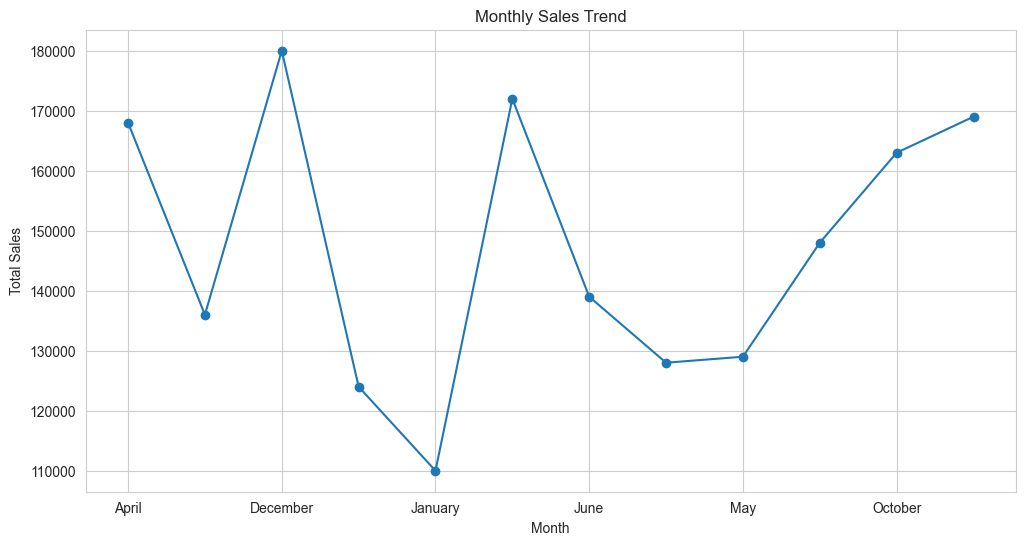

In [11]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

## Visualization 2: Top Selling Products

C:\Users\MONIKA\AppData\Local\Temp\ipykernel_40748\3426782591.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


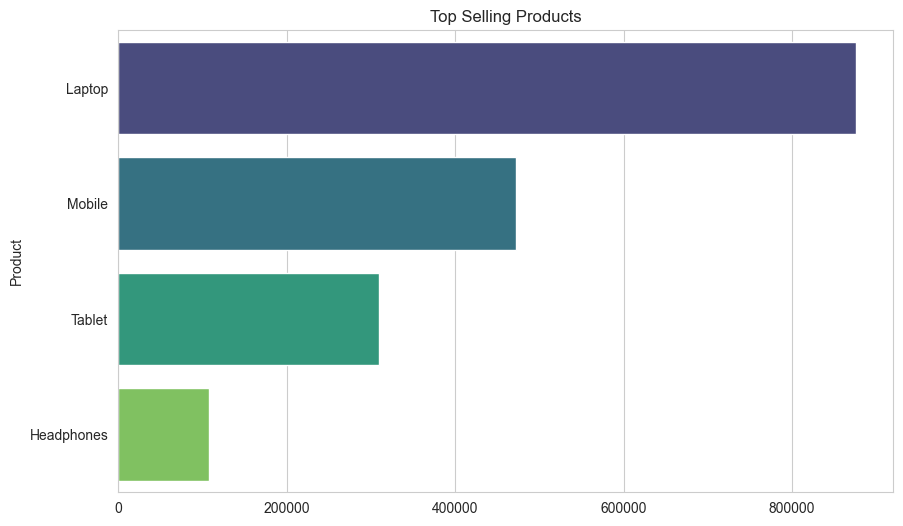

In [12]:
top_products = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette='viridis'
)

plt.title("Top Selling Products")
plt.show()

## Visualization 3: Regional Sales Comparison

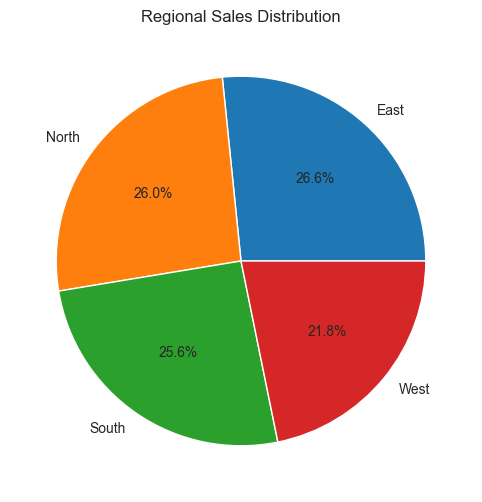

In [13]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.pie(
    region_sales,
    labels=region_sales.index,
    autopct='%1.1f%%'
)

plt.title("Regional Sales Distribution")
plt.show()

## Visualization 4: Profit vs Sales Relationship

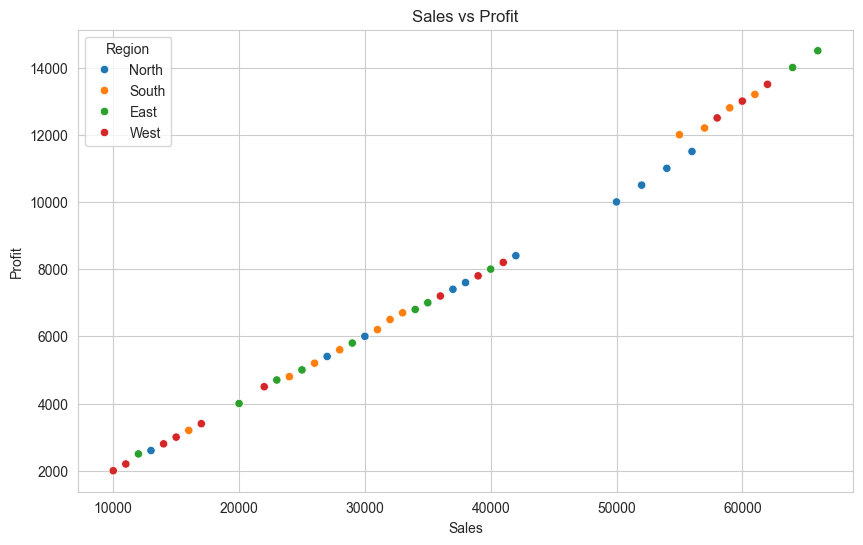

In [14]:
sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    hue='Region'
)

plt.title("Sales vs Profit")
plt.show()

## Heatmap

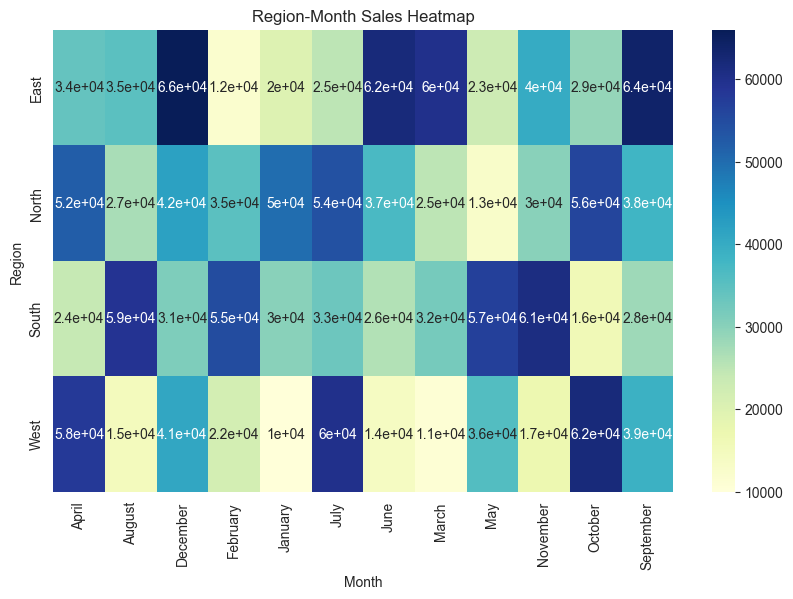

In [15]:
pivot = df.pivot_table(
    values='Sales',
    index='Region',
    columns='Month'
)

sns.heatmap(
    pivot,
    annot=True,
    cmap='YlGnBu'
)

plt.title("Region-Month Sales Heatmap")
plt.show()

## Box Plot

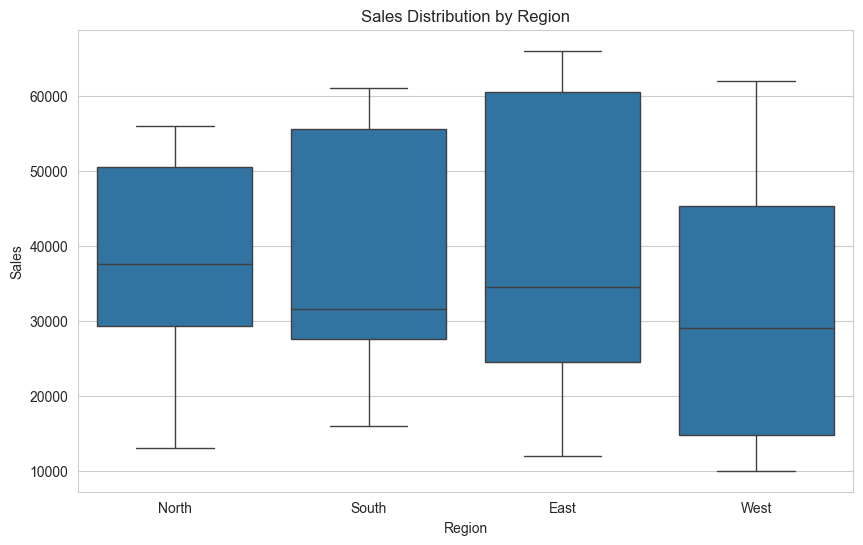

In [16]:
sns.boxplot(
    data=df,
    x='Region',
    y='Sales'
)

plt.title("Sales Distribution by Region")
plt.show()